# 1 · The Limit Order Book

*Module 1 — Market Microstructure*

How a market actually works, one order at a time: the data structure behind every price you see, and the mechanics of how a trade moves that price.

## 1. Motivation

Imagine a large pension fund needs to sell 200,000 shares of a mid-cap stock today. The screen shows a price of €50.00. Naively, you might think the fund receives 200,000 × €50.00. It doesn't. As the sell order executes, it consumes buyers one by one, starting with whoever is willing to pay the most, then the next-most, and so on. By the time the order is filled, the average price is lower than €50.00 — sometimes much lower.

To understand *why*, and to be able to predict *how much* lower, we need to look inside the market: not at the single number on the screen, but at the full **limit order book** — the queue of every buyer and seller currently waiting to trade. This notebook builds one from scratch.

## 2. Intuition

Think of the market as a continuously running two-sided auction. On one side, buyers post the price they are willing to pay ("I'll buy at €49.98"). On the other, sellers post the price they want ("I'll sell at €50.02"). Each of these standing offers is a **limit order**: an instruction to trade, but only at a specified price or better. They sit in the book and wait.

Now suppose someone is in a hurry and just wants to trade *right now*, at whatever price is available. That is a **market order**. It does not wait — it immediately matches against the best waiting offer on the other side. If it is small, it trades against that single best price. If it is large enough to exceed what is available there, it "walks the book": it takes all the liquidity at the best price, then moves to the next best price, and so on, until it is fully filled. This is exactly what happened to the pension fund above.

Two waiting sell orders at the *same* price are ranked by who arrived first — like a queue at a deli counter. This is called **price-time priority**: better prices always trade first, and among equal prices, first-come, first-served.

The gap between the best waiting buy price and the best waiting sell price is the **bid-ask spread**. It is the most immediate, visible signature of liquidity: a tight spread means buyers and sellers agree closely on value; a wide spread means large disagreement, or few participants willing to commit capital.

## 3. Theory

### 3.1 The book as a data structure

A limit order book (LOB) has two sides:

- **Bids**: resting buy orders, each a (price, quantity) pair, grouped by price level.
- **Asks**: resting sell orders, grouped the same way.

At any moment, define the **best bid** $b_1 = \max\{p : p \text{ is a bid price with resting quantity}\}$ and the **best ask** $a_1 = \min\{p : p \text{ is an ask price with resting quantity}\}$. Two quantities follow directly:

$$
\text{mid-price:}\quad m = \frac{b_1 + a_1}{2}, \qquad\qquad \text{bid-ask spread:}\quad s = a_1 - b_1 .
$$

The mid-price is a convenient stand-in for "the" price of the asset, even though no one can actually trade at it — it sits exactly between what buyers and sellers agree to. The *relative* spread $s/m$ makes spreads comparable across assets trading at very different price levels.

Beyond the best price, the book has **depth**: the quantity resting at each price level further from the best. Write $q^{ask}_k$ for the quantity resting at the $k$-th best ask level ($q^{ask}_1$ at $a_1$, $q^{ask}_2$ at the next price up, and so on), and $q^{bid}_k$ analogously for bids.

### 3.2 What happens when a market order arrives

Suppose a market **buy** order of size $Q$ arrives. It consumes ask-side liquidity starting from $a_1$. If $Q \le q^{ask}_1$, it fills entirely at $a_1$. If $Q > q^{ask}_1$, it fills $q^{ask}_1$ shares at $a_1$, then moves to the next level, and so on until $Q$ is exhausted. The **average execution price** is a volume-weighted average over however many levels it had to consume:

$$
P_{avg}(Q) = \frac{1}{Q}\sum_{k=1}^{K} p_k \, q_k^{ask}, \qquad \text{where } K \text{ is the smallest level with } \sum_{j=1}^{K} q_j^{ask} \ge Q,
$$

and the last term $q_K^{ask}$ in the sum is truncated to whatever remains of $Q$ after filling levels $1,\dots,K-1$. Two consequences follow immediately, and both matter enormously in practice:

1. $P_{avg}(Q)$ is **non-decreasing in $Q$** for a buy order — each extra unit fills at a price at least as high as the last — and non-increasing in $Q$ for a sell order.
2. The gap $P_{avg}(Q) - m$, how much worse than the mid-price you did purely because of your own order's size, is called **price impact** or **implementation shortfall**. It is not a fee charged by anyone; it is a mechanical consequence of consuming a finite, price-ordered queue of counterparties.

This idea — that trading costs come from *walking the book*, not from posted commissions — is the foundation of this entire module. In the next notebook we will see that the *slope* of $P_{avg}(Q)$ can be summarized in a single number (Kyle's $\lambda$) and used to compare liquidity across assets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
%matplotlib inline

# Consistent, minimal plot style used across the notebook
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(7)  # fixed seed: every run of this notebook gives the same numbers

## 4. Implementation

We build the book in three pieces: (1) a `LimitOrderBook` class implementing price-time priority exactly as defined above, (2) a simulator that generates a realistic stream of limit and market orders, and (3) the price-impact function $P_{avg}(Q)$, coded directly from its definition.

### 4.1 The order book class

In [2]:
class LimitOrderBook:
    """
    A two-sided limit order book with price-time priority.

    self.bids / self.asks: dict mapping price -> deque of [order_id, quantity].
    Within a price level, orders are stored oldest-first (a deque), so the
    order that arrived first is always filled first. sorted(prices) gives
    price priority; the deque gives time priority -- together, price-time
    priority exactly as defined in Section 3.1.
    """
    def __init__(self):
        self.bids = {}
        self.asks = {}
        self._next_id = 0
        self.trade_log = []  # (time, price, quantity, aggressor_side)

    def _new_id(self):
        self._next_id += 1
        return self._next_id

    def best_bid(self):
        return max(self.bids) if self.bids else None

    def best_ask(self):
        return min(self.asks) if self.asks else None

    def mid_price(self):
        b, a = self.best_bid(), self.best_ask()
        return None if (b is None or a is None) else 0.5 * (b + a)

    def spread(self):
        b, a = self.best_bid(), self.best_ask()
        return None if (b is None or a is None) else a - b

    def depth_at(self, side, price):
        book = self.bids if side == 'buy' else self.asks
        return sum(q for _, q in book.get(price, []))

    def add_limit_order(self, side, price, qty):
        """Add a resting limit order. side: 'buy' or 'sell'."""
        book = self.bids if side == 'buy' else self.asks
        book.setdefault(price, deque()).append([self._new_id(), qty])

    def process_market_order(self, side, qty, t=None):
        """
        Execute a market order of size `qty`. side='buy' hits the ask side,
        side='sell' hits the bid side. Walks the book level by level, filling
        the oldest resting order at each level first (price-time priority).
        Returns (avg_fill_price, filled_qty, unfilled_qty).
        """
        book = self.asks if side == 'buy' else self.bids
        remaining, filled_value = qty, 0.0
        levels = sorted(book.keys()) if side == 'buy' else sorted(book.keys(), reverse=True)
        for price in levels:
            if remaining <= 0:
                break
            queue = book[price]
            while queue and remaining > 0:
                order_id, order_qty = queue[0]
                take = min(order_qty, remaining)
                filled_value += take * price
                remaining -= take
                order_qty -= take
                queue[0][1] = order_qty
                if order_qty == 0:
                    queue.popleft()
                self.trade_log.append((t, price, take, side))
            if not queue:
                del book[price]
        filled = qty - remaining
        avg_price = filled_value / filled if filled > 0 else None
        return avg_price, filled, remaining

In [3]:
# Quick manual sanity check: build a tiny book by hand and inspect it
lob = LimitOrderBook()
lob.add_limit_order('buy',  49.98, 300)
lob.add_limit_order('buy',  49.97, 500)
lob.add_limit_order('sell', 50.02, 200)
lob.add_limit_order('sell', 50.03, 400)

print(f"Best bid: {lob.best_bid()}   Best ask: {lob.best_ask()}")
print(f"Mid-price: {lob.mid_price():.3f}   Spread: {lob.spread():.3f}")

# A market buy for 350 shares should fill 200 at 50.02, then 150 at 50.03
avg_px, filled, unfilled = lob.process_market_order('buy', 350, t=0)
print(f"\nMarket buy of 350 shares -> avg price {avg_px:.4f}, filled {filled}, unfilled {unfilled}")
print(f"New best ask: {lob.best_ask()}  (depth left there: {lob.depth_at('sell', 50.03)})")

Best bid: 49.98   Best ask: 50.02
Mid-price: 50.000   Spread: 0.040

Market buy of 350 shares -> avg price 50.0243, filled 350, unfilled 0
New best ask: 50.03  (depth left there: 250)


### 4.2 Simulating a realistic order flow

A real book is never static — orders arrive continuously, at random times, from many independent participants. We use a standard, simple approach from the market-microstructure literature: treat order arrivals as independent random ("Poisson") processes, one each for limit buys, limit sells, market buys, and market sells. This "zero-intelligence" style of model (see Cont, Stoikov & Talreja, 2010, for a rigorous version) ignores strategy entirely — orders arrive with no memory of what came before — yet it already reproduces a surprising amount of what a real book looks like. We return to what it misses in Section 6.

Limit orders are placed at a random distance from the current mid-price, drawn from a geometric distribution (the discrete analogue of the exponential — a natural choice here since ticks are discrete steps, not a continuum): most participants want to trade close to the current price, but some are willing to wait further away for a better one. Market orders arrive with a random size and immediately consume liquidity.

In [4]:
def simulate_lob(n_events=2000, p_market=0.30, tick=0.01, start_price=50.00, seed=0):
    """
    Simulate a limit order book over n_events random order arrivals.
    Returns the final LimitOrderBook plus a DataFrame logging mid-price and
    spread after every event (used for the time-series plots below).
    """
    local_rng = np.random.default_rng(seed)
    lob = LimitOrderBook()

    # Seed the book with a starting ladder of resting orders so the very
    # first events have something to interact with.
    for k in range(1, 11):
        lob.add_limit_order('buy',  round(start_price - k * tick, 2), int(local_rng.integers(20, 150)))
        lob.add_limit_order('sell', round(start_price + k * tick, 2), int(local_rng.integers(20, 150)))

    history = []
    t = 0.0
    for _ in range(n_events):
        t += local_rng.exponential(1.0)  # exponential inter-arrival times => a Poisson process
        mid = lob.mid_price()
        if mid is None:
            break

        if local_rng.random() < p_market:
            # Market order: random side, random size
            side = 'buy' if local_rng.random() < 0.5 else 'sell'
            qty = int(local_rng.integers(10, 150))
            lob.process_market_order(side, qty, t=t)
        else:
            # Limit order: random side, price offset from mid via a geometric
            # distance (in ticks; geometric always returns >= 1). Orders never
            # cross the mid, which keeps the simulation well-behaved.
            side = 'buy' if local_rng.random() < 0.5 else 'sell'
            offset_ticks = int(local_rng.geometric(0.15))
            qty = int(local_rng.integers(20, 150))
            price = round(mid - offset_ticks * tick, 2) if side == 'buy' else round(mid + offset_ticks * tick, 2)
            lob.add_limit_order(side, price, qty)

        history.append({'t': t, 'mid': lob.mid_price(), 'spread': lob.spread(),
                         'best_bid': lob.best_bid(), 'best_ask': lob.best_ask()})

    return lob, pd.DataFrame(history)

lob, hist = simulate_lob(n_events=2000, seed=7)
print(f"Simulated {len(hist)} events.")
hist.tail()

Simulated 2000 events.


,t,mid,spread,best_bid,best_ask
1995,1932.584955,49.995,0.03,49.98,50.01
1996,1933.544115,49.995,0.03,49.98,50.01
1997,1936.682467,49.995,0.03,49.98,50.01
1998,1937.547653,49.995,0.03,49.98,50.01
1999,1937.609746,49.995,0.03,49.98,50.01


### 4.3 Looking at a snapshot of the book

A "depth chart" shows resting quantity on each side of the book at a single instant — this is what a trader looking at Level 2 market data actually sees.

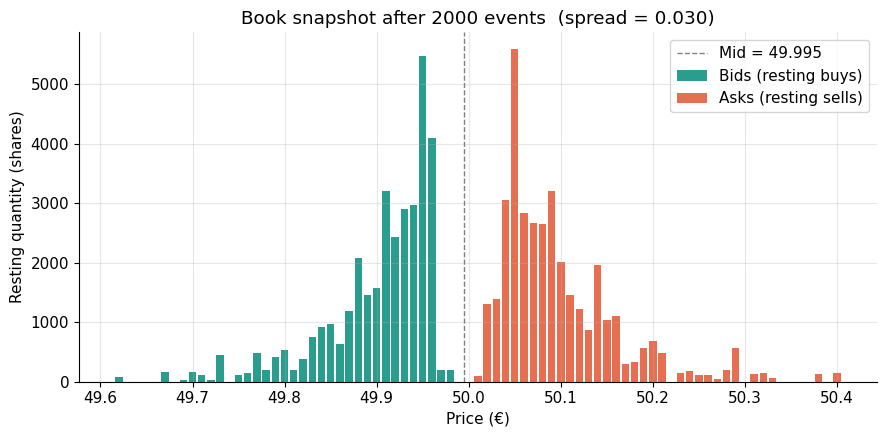

In [5]:
def plot_depth(lob, title="Order book snapshot"):
    bid_prices = sorted(lob.bids.keys(), reverse=True)
    ask_prices = sorted(lob.asks.keys())
    bid_qty = [lob.depth_at('buy', p) for p in bid_prices]
    ask_qty = [lob.depth_at('sell', p) for p in ask_prices]

    fig, ax = plt.subplots()
    ax.bar(bid_prices, bid_qty, width=0.008, color='#2a9d8f', label='Bids (resting buys)')
    ax.bar(ask_prices, ask_qty, width=0.008, color='#e76f51', label='Asks (resting sells)')
    ax.axvline(lob.mid_price(), color='gray', linestyle='--', linewidth=1, label=f'Mid = {lob.mid_price():.3f}')
    ax.set_xlabel('Price (€)')
    ax.set_ylabel('Resting quantity (shares)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_depth(lob, title=f"Book snapshot after {len(hist)} events  (spread = {lob.spread():.3f})")

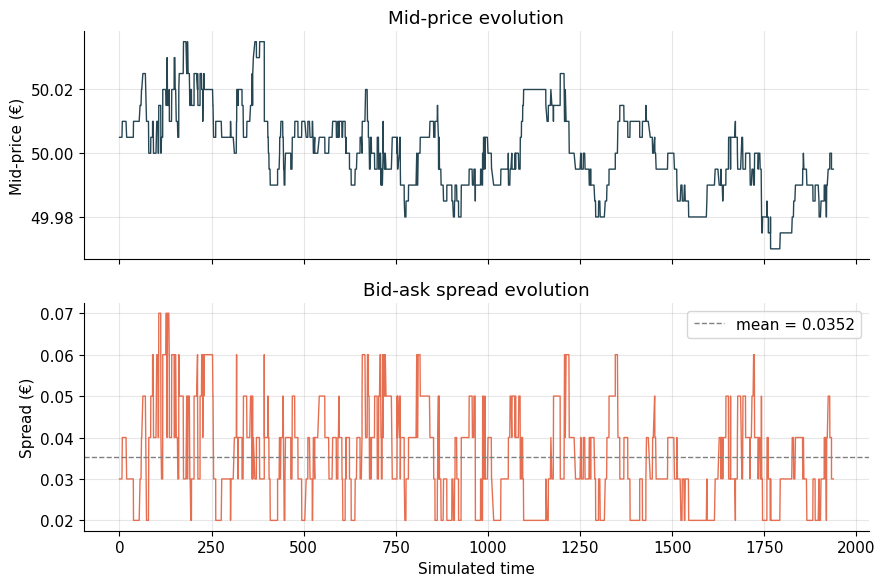

Mean spread: 0.0352  |  Std: 0.0119  |  Min: 0.0200  |  Max: 0.0700


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(hist['t'], hist['mid'], color='#264653', linewidth=1)
axes[0].set_ylabel('Mid-price (€)')
axes[0].set_title('Mid-price evolution')

axes[1].plot(hist['t'], hist['spread'], color='#e76f51', linewidth=1)
axes[1].axhline(hist['spread'].mean(), color='gray', linestyle='--', linewidth=1,
                 label=f"mean = {hist['spread'].mean():.4f}")
axes[1].set_ylabel('Spread (€)')
axes[1].set_xlabel('Simulated time')
axes[1].set_title('Bid-ask spread evolution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean spread: {hist['spread'].mean():.4f}  |  Std: {hist['spread'].std():.4f}  "
      f"|  Min: {hist['spread'].min():.4f}  |  Max: {hist['spread'].max():.4f}")

## 5. Worked example: pricing the cost of a large order

Now we implement $P_{avg}(Q)$ exactly as derived in Section 3.2, and use it to answer the pension fund's question from the introduction: **how much does it cost, in price terms, to trade a large block right now?**

Crucially, this function only *looks* at the book — it does not modify it. That lets us trace out the whole price-impact curve, for a full range of order sizes, from a single snapshot.

In [7]:
def hypothetical_avg_price(lob, side, Q):
    """
    Volume-weighted average price a market order of size Q would get RIGHT NOW,
    without actually sending the order (a non-destructive walk of the book).
    side='buy' walks the ask side; side='sell' walks the bid side.
    """
    book = lob.asks if side == 'buy' else lob.bids
    levels = sorted(book.keys()) if side == 'buy' else sorted(book.keys(), reverse=True)
    remaining, value = Q, 0.0
    for price in levels:
        depth_here = sum(q for _, q in book[price])
        take = min(depth_here, remaining)
        value += take * price
        remaining -= take
        if remaining <= 0:
            break
    filled = Q - remaining
    return (value / filled if filled > 0 else None), filled

# Total resting depth on the ask side tells us how far we can push Q
max_depth = sum(lob.depth_at('sell', p) for p in lob.asks)
sizes = np.arange(10, max_depth, 10)
mid = lob.mid_price()

impact_bps = []
for Q in sizes:
    avg_px, filled = hypothetical_avg_price(lob, 'buy', int(Q))
    impact_bps.append((avg_px - mid) / mid * 1e4 if avg_px else np.nan)  # basis points vs mid

impact_df = pd.DataFrame({'Q': sizes, 'impact_bps': impact_bps}).dropna()
print(f"Visible ask-side depth: {max_depth} shares")
impact_df.head()

Visible ask-side depth: 36799 shares


,Q,impact_bps
0,10,3.0003
1,20,3.0003
2,30,3.0003
3,40,3.0003
4,50,3.0003


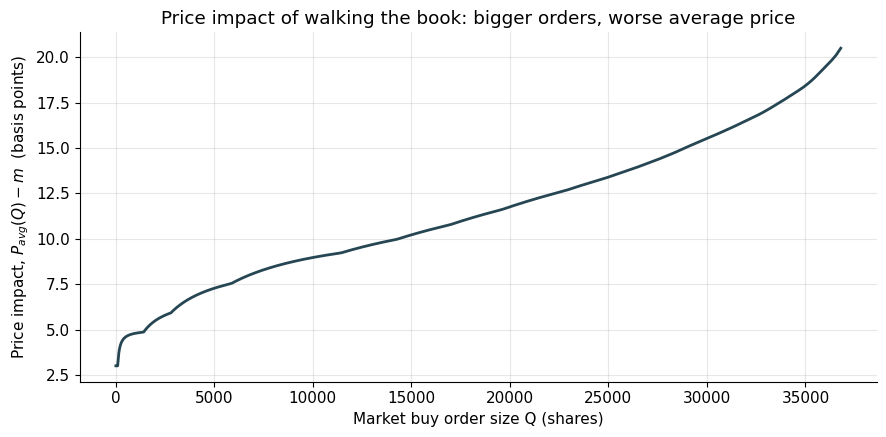

Buying   500 shares now: avg price €50.0179  (+4.6 bps vs mid €49.9950)
Buying  2000 shares now: avg price €50.0224  (+5.5 bps vs mid €49.9950)
Buying  5000 shares now: avg price €50.0314  (+7.3 bps vs mid €49.9950)


In [8]:
fig, ax = plt.subplots()
ax.plot(impact_df['Q'], impact_df['impact_bps'], color='#264653', linewidth=2)
ax.set_xlabel('Market buy order size Q (shares)')
ax.set_ylabel(r'Price impact, $P_{avg}(Q) - m$  (basis points)')
ax.set_title('Price impact of walking the book: bigger orders, worse average price')
plt.tight_layout()
plt.show()

# The pension fund's question, made concrete:
for Q in [500, 2000, 5000]:
    if Q <= max_depth:
        avg_px, filled = hypothetical_avg_price(lob, 'buy', Q)
        print(f"Buying {Q:>5} shares now: avg price €{avg_px:.4f}  "
              f"({(avg_px - mid)/mid*1e4:+.1f} bps vs mid €{mid:.4f})")
    else:
        print(f"Buying {Q:>5} shares: exceeds visible depth ({max_depth} shares) -- cannot be fully filled")

### Interpreting the result

The curve is non-decreasing, and it steepens as $Q$ grows. Small orders barely move the average price, because they only need the first level or two of depth. Larger orders must reach further into the book, where resting quantity is sparser in our simulation — a direct consequence of the exponential-distance placement rule: orders far from the mid are rarer. This is exactly the mechanism behind the pension fund's problem from the Motivation: their 200,000-share order did not get a "bad price" because of some hidden fee. It got a worse price because it had to walk deep into a finite queue of buyers.

This also previews the rest of Module 1: the *slope* of this curve is a hands-on version of what Kyle's $\lambda$ formalizes in the next notebook, and the fact that the book *thins out* the deeper you go is precisely what "liquidity" means at a mechanical level.

## 6. Limitations and pitfalls

- **Zero intelligence, zero strategy.** Real participants react to the book: they cancel orders when the price moves against them, place iceberg (partially hidden) orders, and adjust aggressiveness based on what they observe. Our simulator's orders arrive with no memory and no reaction to the current state — a simplification, not a model of real behavior.
- **No informed trading.** Every market order here is pure, undirected noise: a coin flip decides its side. Real order flow contains participants who trade because they know something the market maker does not — the subject of the very next notebook, which fundamentally changes how the spread should be set.
- **Order arrivals are not actually Poisson.** Real order flow is *self-exciting*: one trade tends to trigger a cluster of others (news, algorithmic reactions, cascading stop-losses). A Poisson process has no memory of past events and therefore cannot produce this clustering. Module 4's Hawkes process (Notebook 18) is built specifically to fix this.
- **No cancellations.** Real limit orders are frequently cancelled before they trade, often within milliseconds. Our book only ever grows unless consumed by a market order, making it more one-directional than a real book — Exercise 2 asks you to fix this.
- **Single venue, no latency, an idealized tick grid.** Real trading happens across multiple competing venues, with network latency between participants and the exchange, and with a minimum tick size that binds in ways this notebook does not fully enforce.

## 7. Exercises

**1. Spread statistics (warm-up).**
Using the `hist` DataFrame from the simulation, compute the mean and standard deviation of the spread, and plot a histogram of its distribution. Is the spread ever zero? Given the definition $s = a_1 - b_1$ and the rule that limit orders never cross the mid, what is the smallest possible spread in this simulator, and why?

**2. Add cancellations.**
Extend `simulate_lob` with a fifth event type: order cancellation. With some probability, pick a random resting order anywhere in the book and remove it entirely. Re-run the simulation and compare average book depth and average spread to the original version. Does the book become thinner? Does the spread widen?

**3. From the impact curve to a liquidity number.**
Fit a straight line (simple linear regression, no intercept) to `impact_bps` as a function of `Q`, using only small-to-medium order sizes (say, up to 30% of `max_depth`). The slope of that line is a crude, single-number summary of "how illiquid is this book" — sound familiar? Now generate a *second* book snapshot using `p_market=0.55` instead of `0.30` (a much more market-order-heavy, thinner simulated book) and repeat the fit. Which book is more liquid by this measure, and does that match what a depth chart of each shows by eye? Keep this result in mind — Notebook 2 makes the idea precise and gives it a name.